# Ejercicio en clase 2 — TensorFlow Lite + Detección de Anomalías

**IA en Dispositivos Móviles y Embebidos · UAO 2026-2**
Profesor: Juan Camilo Giraldo Londoño · Estudiante: César Armando Reyes Oliveros
Proyecto: **Coctelera TinyML (MixLab)** — `github.com/caesar-dat-com/miniproyecto1-tinyml`

---

## Qué cubre este cuaderno

Los dos materiales de la semana 9, cada uno con su parte práctica:

| Material del curso | Parte de este cuaderno |
|---|---|
| *Intro Tensorflow Lite* | **Parte 1** — entrenar → convertir a int8 → medir el costo → generar el array C |
| *TinyML UAO · Detección de Anomalías* | **Parte 2** — características espectrales → K-means → puntaje de anomalía |

## Cómo está construido

Corre **de principio a fin sin subir nada**: la primera celda descarga las 60
tomas reales desde el repositorio público del proyecto. No hay datos
sintéticos, no hay rutas locales que haya que ajustar.

Cada sección responde tres preguntas, en este orden: **qué se hizo**, **por qué
así** y **qué contestar si el profesor pregunta**. Esa última parte está en
bloques citados como este:

> 🗣 **Para sustentar:** lo que conviene decir, con las cifras a la mano.

## El dato más importante de todo el cuaderno

La frecuencia de muestreo **no es 100 Hz: es 62,5 Hz**. El campo
`interval_ms` del export vale 16,0 ms, y 1000/16 = 62,5. Si alguien asume
100 Hz, todas las frecuencias del análisis espectral quedan corridas un 60 %.
La celda 3 lo verifica con un `assert` para que el cuaderno **se niegue a
seguir** si el dataset cambia.

---
# 1 · Preparación y descarga del dataset

Las 60 tomas viven en el repositorio público del proyecto, así que se bajan
directo. `info-6clases.labels` es el archivo de etiquetas **corregido**: el
export original de Edge Impulse (`info.labels`) trae una etiqueta distinta por
toma — `Agitar 01`, `Agitar 02`… — es decir **60 clases de una muestra cada
una**, con las que ningún modelo aprende nada. Ese fue el hallazgo D1 del
proyecto.

In [1]:
%pip install -q cbor2

import os, json, pathlib, urllib.parse, urllib.request, concurrent.futures
import numpy as np

REPO = "https://raw.githubusercontent.com/caesar-dat-com/miniproyecto1-tinyml/main"
BASE = f"{REPO}/edge-impulse/dataset"
RAIZ = pathlib.Path("dataset")
(RAIZ / "training").mkdir(parents=True, exist_ok=True)


def baja(url, destino):
    if destino.exists() and destino.stat().st_size > 0:
        return 0
    with urllib.request.urlopen(url, timeout=60) as r:
        destino.write_bytes(r.read())
    return 1


baja(f"{BASE}/info-6clases.labels", RAIZ / "info-6clases.labels")
info = json.loads((RAIZ / "info-6clases.labels").read_text())
print(f"etiquetas: {len(info['files'])} tomas declaradas")

# en paralelo: 60 descargas de ~25 KB tardan segundos
tareas = [(f"{BASE}/{urllib.parse.quote(e['path'])}", RAIZ / e["path"]) for e in info["files"]]
with concurrent.futures.ThreadPoolExecutor(max_workers=8) as ex:
    nuevas = sum(ex.map(lambda t: baja(*t), tareas))

faltan = [d for _, d in tareas if not d.exists() or d.stat().st_size == 0]
assert not faltan, f"no se bajaron {len(faltan)} tomas"
print(f"dataset listo en {RAIZ.resolve()}  ({nuevas} descargadas ahora)")

/home/ares/.hermes/installs/100fc48b179af71f/environments/09e4fc7be0af44da9ccc0984aec7d9d9/venv/bin/python3: No module named pip


Note: you may need to restart the kernel to use updated packages.


etiquetas: 60 tomas declaradas


dataset listo en /home/ares/.hermes/cache/scratch/ejec/dataset  (60 descargadas ahora)


---
# 2 · Decodificar el CBOR y verificar la frecuencia

Edge Impulse exporta cada toma en **CBOR**, un formato binario compacto. Dentro
hay un diccionario con `payload.values` (la matriz de muestras),
`payload.sensors` (los nombres de los 9 ejes) y `payload.interval_ms`.

El `assert` de abajo es deliberado: si algún día el dataset se regraba a otra
frecuencia, el cuaderno falla en voz alta en vez de producir resultados
silenciosamente equivocados.

In [2]:
import cbor2

SENSORES_9 = ['accX','accY','accZ','gyrX','gyrY','gyrZ','magX','magY','magZ']


def cargar_dataset(raiz):
    """Lee las etiquetas corregidas y decodifica cada .cbor.

    Devuelve dicts con: nombre, archivo (= grupo del split), clase,
    valores (N x 9 float32), sensores e interval_ms.
    """
    info = json.loads((pathlib.Path(raiz) / 'info-6clases.labels').read_text())
    tomas = []
    for e in info['files']:
        ruta = pathlib.Path(raiz) / e['path']
        with open(ruta, 'rb') as fh:
            d = cbor2.load(fh)
        pl = d['payload']
        tomas.append(dict(
            nombre      = e['name'],
            archivo     = ruta.name,                  # grupo para el split por toma
            clase       = e['label']['label'],
            valores     = np.asarray(pl['values'], dtype=np.float32),
            sensores    = [s['name'] for s in pl['sensors']],
            interval_ms = float(pl['interval_ms']),
        ))
    return tomas


tomas  = cargar_dataset(RAIZ)
CLASES = sorted({t['clase'] for t in tomas})
print(f"{len(tomas)} tomas · {len(CLASES)} clases: {CLASES}")

intervalos = {t['interval_ms'] for t in tomas}
assert intervalos == {16.0}, f"interval_ms inesperado: {intervalos}"
FS = 1000.0 / 16.0
print(f"\ninterval_ms = 16,0  ->  fs = {FS} Hz   (NO 100 Hz)")
print(f"sensores en el export: {tomas[0]['sensores']}")

import collections, pandas as pd
inv = collections.defaultdict(list)
for t in tomas:
    inv[t['clase']].append(len(t['valores']))
tabla = pd.DataFrame([{'clase': c, 'tomas': len(inv[c]),
                       'muestras_min': min(inv[c]), 'muestras_max': max(inv[c]),
                       'segundos': round(min(inv[c]) / FS, 2)} for c in CLASES])
print()
print(tabla.to_string(index=False))

60 tomas · 6 clases: ['agitar', 'macerar', 'remover', 'reposo', 'reposo_mano', 'servir']

interval_ms = 16,0  ->  fs = 62.5 Hz   (NO 100 Hz)
sensores en el export: ['accX', 'accY', 'accZ', 'gyrX', 'gyrY', 'gyrZ', 'magX', 'magY', 'magZ']



      clase  tomas  muestras_min  muestras_max  segundos
     agitar     10           251           626      4.02
    macerar     10           626           626     10.02
    remover     10           251           251      4.02
     reposo     10           626           626     10.02
reposo_mano     10           626           626     10.02
     servir     10           626           626     10.02


> 🗣 **Para sustentar:** *«El dataset son 60 tomas del Nano 33 BLE a 62,5 Hz,
> nueve ejes, diez tomas por clase. `remover` dura 4 segundos y el resto 10;
> esa desigualdad está documentada como hallazgo D4 y se corrige con
> `class_weight` al entrenar.»*

**Las clases:** `agitar`, `macerar`, `remover`, `servir` son los gestos de
coctelería; `reposo` es la coctelera quieta sobre la mesa y `reposo_mano` es
sostenida en la mano sin agitar. Falta `colar`, el quinto gesto del diseño
original — hallazgo D2, sin capturar todavía.

---
# 3 · Ejes y ventaneo

**Solo entra el acelerómetro.** Dos decisiones, y conviene separarlas porque se
tomaron por razones distintas:

- **`mag*` (magnetómetro) fuera por diseño.** Codifica orientación y campo
  magnético del sitio, no el gesto. Incluirlo *sube* la exactitud, y
  precisamente por eso es una fuga: el modelo aprendería a reconocer la mesa
  donde se grabó, no el movimiento.
- **`gyr*` (giroscopio) fuera por medición.** Se probó añadirlo y **empeora**
  en validación cruzada agrupada. No es intuición, es el resultado del
  experimento de ablación del notebook 03.

Con 3 ejes la Vía A da exactamente las 39 características del PDF del profesor.

**Ventana de 125 muestras (2,00 s) con paso de 25 (0,4 s, 80 % de solape).** Un
gesto de coctelería completo dura alrededor de dos segundos; el solape alto
multiplica las ventanas de entrenamiento sin inventar datos.

In [3]:
EJES_ACC, EJES_GIR, EJES_MAG = ['accX','accY','accZ'], ['gyrX','gyrY','gyrZ'], ['magX','magY','magZ']
EJES_USADOS = EJES_ACC

W, S = 125, 25
assert abs(W / FS - 2.0) < 1e-9, 'W debe equivaler a 2 s a 62,5 Hz'


def selecciona_ejes(toma, ejes):
    idx = [toma['sensores'].index(a) for a in ejes]
    return toma['valores'][:, idx]


def ventanear(tomas, ejes, W, S):
    """Ventanas deslizantes. Devuelve X (n,W,C), y (clase) y g (archivo origen).

    `g` es lo que agrupa el split: todas las ventanas de una toma caen del mismo
    lado de la partición. Sin eso, ventanas solapadas de la misma grabación
    acaban en train y en test y la exactitud sale inflada.
    """
    X, y, g = [], [], []
    for t in tomas:
        m = selecciona_ejes(t, ejes)
        for i in range(0, len(m) - W + 1, S):
            X.append(m[i:i+W]); y.append(t['clase']); g.append(t['archivo'])
    return np.asarray(X, np.float32), np.asarray(y), np.asarray(g)


X, y, g = ventanear(tomas, EJES_USADOS, W, S)
print(f"X {X.shape}  ({X.shape[0]} ventanas × {W} muestras × {X.shape[2]} ejes)")
print(f"ventana = {W/FS:.2f} s · paso = {S/FS:.2f} s · solape = {100*(1-S/W):.0f} %")
print(f"tomas distintas (grupos del split): {len(set(g))}\n")
rep = pd.Series(y).value_counts().reindex(CLASES)
rep_pct = (100 * rep / rep.sum()).round(1)
print(pd.DataFrame({'ventanas': rep, '%': rep_pct}).to_string())

X (1020, 125, 3)  (1020 ventanas × 125 muestras × 3 ejes)
ventana = 2.00 s · paso = 0.40 s · solape = 80 %
tomas distintas (grupos del split): 60

             ventanas     %
agitar            120  11.8
macerar           210  20.6
remover            60   5.9
reposo            210  20.6
reposo_mano       210  20.6
servir            210  20.6


`remover` aporta muchas menos ventanas que el resto — consecuencia directa de
durar 4 segundos en vez de 10. Es el hallazgo D4 del proyecto y se compensa con
`class_weight` en el entrenamiento, no borrando datos.

---
# 4 · Partición por toma, nunca por ventana

Este es el error más fácil de cometer en TinyML con sensores y el que más
infla los resultados. Dos ventanas consecutivas con 80 % de solape son casi la
misma señal: si una cae en entrenamiento y la otra en prueba, el modelo ya vio
la respuesta y la exactitud sale regalada.

La partición se hace **por archivo de origen** con `GroupShuffleSplit`. Y hay
un detalle: ese generador no estratifica, así que con 60 grupos y 6 clases una
partición puede dejar una clase entera fuera de la prueba. Por eso se recorren
varias particiones y se toma la primera donde las 6 clases aparecen a ambos
lados — sigue siendo partición por toma pura.

In [4]:
from sklearn.model_selection import GroupShuffleSplit


def split_por_toma(y, g, test_size=0.25, seed=42, n_try=50):
    clases = set(y)
    gss = GroupShuffleSplit(n_splits=n_try, test_size=test_size, random_state=seed)
    for k, (tr, te) in enumerate(gss.split(np.zeros(len(y)), y, groups=g)):
        if set(y[tr]) == clases and set(y[te]) == clases:
            return tr, te, k
    raise RuntimeError(f'ninguna de las {n_try} particiones cubre las {len(clases)} clases')


def verifica_sin_fuga(g, idx_a, idx_b, nombre_a='train', nombre_b='test'):
    ta, tb = set(g[idx_a]), set(g[idx_b])
    comunes = ta & tb
    assert not comunes, f'FUGA: {len(comunes)} tomas en {nombre_a} y {nombre_b}'
    print(f'sin fuga: {len(ta)} tomas en {nombre_a}, {len(tb)} en {nombre_b}, 0 compartidas')


tr_val, i_test, k = split_por_toma(y, g, test_size=0.25, seed=42)
sub_tr, sub_val, _ = split_por_toma(y[tr_val], g[tr_val], test_size=0.20, seed=43)
i_train, i_val = tr_val[sub_tr], tr_val[sub_val]

print(f'partición GroupShuffleSplit #{k}\n')
verifica_sin_fuga(g, i_train, i_test, 'train', 'test')
verifica_sin_fuga(g, i_val, i_test, 'val', 'test')
verifica_sin_fuga(g, i_train, i_val, 'train', 'val')

cuentas = pd.DataFrame({
    'train': pd.Series(y[i_train]).value_counts(),
    'val':   pd.Series(y[i_val]).value_counts(),
    'test':  pd.Series(y[i_test]).value_counts()}).reindex(CLASES).fillna(0).astype(int)
cuentas.loc['TOTAL ventanas'] = cuentas.sum()
cuentas.loc['TOTAL tomas'] = [len(set(g[i])) for i in (i_train, i_val, i_test)]
print('\n', cuentas.to_string())

partición GroupShuffleSplit #1

sin fuga: 36 tomas en train, 15 en test, 0 compartidas
sin fuga: 9 tomas en val, 15 en test, 0 compartidas
sin fuga: 36 tomas en train, 9 en val, 0 compartidas

                 train  val  test
agitar             81   12    27
macerar           147   21    42
remover            24   18    18
reposo            168   21    21
reposo_mano       105   21    84
servir            126   21    63
TOTAL ventanas    651  114   255
TOTAL tomas        36    9    15


> 🗣 **Para sustentar:** *«La partición es por toma, no por ventana, y lo
> verifico con un assert que compara los conjuntos de archivos. Si partiera por
> ventana la exactitud subiría varios puntos, pero serían falsos: ventanas
> solapadas de la misma grabación en train y en test.»*

---
# 5 · Normalización

Se calculan media y desviación **solo con el entrenamiento** y con esas mismas
constantes se transforman validación y prueba. Que el test no quede con media 0
y desviación 1 exactas es lo correcto: si quedara perfecto significaría que se
usó información del test para normalizar.

Estas seis constantes hay que **copiarlas al sketch del Arduino**: en el
dispositivo hay que aplicar exactamente la misma transformación antes de la
inferencia, o el modelo recibe números en otra escala y acierta al azar.

In [5]:
def normalizador(A):
    mu = A.reshape(-1, A.shape[-1]).mean(0)
    sd = A.reshape(-1, A.shape[-1]).std(0) + 1e-8
    return mu, sd


IX = {c: i for i, c in enumerate(CLASES)}
a_idx = lambda v: np.array([IX[c] for c in v])

mu, sd = normalizador(X[i_train])
norm = lambda A: ((A - mu) / sd).astype('f4')
Xtr, Xva, Xte = norm(X[i_train]), norm(X[i_val]), norm(X[i_test])
y_train, y_val, y_test = a_idx(y[i_train]), a_idx(y[i_val]), a_idx(y[i_test])

print('constantes de normalización — COPIAR AL SKETCH DEL ARDUINO')
for e, m_, s_ in zip(EJES_USADOS, mu, sd):
    print(f'  {e}: media = {m_:+.6f}   desv = {s_:.6f}')
print(f'\nXtr {Xtr.shape}  media {Xtr.mean():+.4f}  desv {Xtr.std():.4f}')
print(f'Xte {Xte.shape}  media {Xte.mean():+.4f}  desv {Xte.std():.4f}'
      '   <- no tiene por qué dar 0/1, y eso está bien')

constantes de normalización — COPIAR AL SKETCH DEL ARDUINO
  accX: media = +0.394650   desv = 4.489280
  accY: media = -6.032119   desv = 7.683932
  accZ: media = +1.670152   desv = 3.227568

Xtr (651, 125, 3)  media +0.0000  desv 1.0000
Xte (255, 125, 3)  media +0.1061  desv 0.9101   <- no tiene por qué dar 0/1, y eso está bien


---
---
# PARTE 1 · TensorFlow Lite

> Material del curso: **Intro Tensorflow Lite**

El flujo que plantea el PDF es:

**entrenar el modelo → convertirlo → optimizarlo → desplegarlo en el edge →
inferir en el edge**

TFLite existe porque un modelo de Keras normal no cabe ni corre en un
microcontrolador. Las cinco limitaciones que resuelve, según el PDF: latencia
(no hay ida y vuelta al servidor), privacidad (ningún dato sale del
dispositivo), conectividad (funciona sin internet), tamaño y consumo.

## 6 · El modelo: Conv1D sobre la ventana cruda

Arquitectura pensada para caber en el nRF52840 del Nano 33 BLE:

`Conv1D(16,5) → MaxPool(3) → Conv1D(32,5) → MaxPool(3) → Conv1D(32,3) → GlobalAveragePooling → Dropout → softmax`

Por qué así:

- **Kernel 5 a 62,5 Hz cubre 80 ms**: la escala de un golpe de hielo dentro de
  la coctelera.
- **Dos MaxPool de 3** reducen 125 → 41 → 13 pasos. La tercera convolución ve
  entonces un campo receptivo de 43 muestras (0,69 s): buena parte de la escala
  del gesto completo.
- **GlobalAveragePooling en vez de Flatten+Dense** quita de golpe la mayoría de
  los pesos — un Flatten daría 13×32 = 416 entradas a la densa — y hace el
  modelo indiferente a *en qué momento* de la ventana ocurre el gesto.
- **Sin capa densa intermedia**: con unas mil ventanas de entrenamiento, cada
  parámetro extra es sobreajuste.

In [6]:
import warnings, logging
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
tf.get_logger().setLevel(logging.ERROR)
print('TensorFlow', tf.__version__)


def construye_modelo(W, n_ejes, n_clases, semilla=42):
    keras.utils.set_random_seed(semilla)
    m = keras.Sequential([
        keras.layers.Input((W, n_ejes), name='ventana'),
        keras.layers.Conv1D(16, 5, activation='relu', padding='same', name='conv_16'),
        keras.layers.MaxPooling1D(3, name='pool_1'),
        keras.layers.Conv1D(32, 5, activation='relu', padding='same', name='conv_32a'),
        keras.layers.MaxPooling1D(3, name='pool_2'),
        keras.layers.Conv1D(32, 3, activation='relu', padding='same', name='conv_32b'),
        keras.layers.GlobalAveragePooling1D(name='gap'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(n_clases, activation='softmax', name='salida'),
    ], name='via_b')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m


def pesos_de_clase(y_idx, n_clases):
    """class_weight inverso a la frecuencia: compensa que `remover` aporte
    muchas menos ventanas (hallazgo D4)."""
    return {i: len(y_idx) / (n_clases * max(1, int((y_idx == i).sum())))
            for i in range(n_clases)}


modelo = construye_modelo(W, len(EJES_USADOS), len(CLASES))
modelo.summary()
cw = pesos_de_clase(y_train, len(CLASES))
print('\nclass_weight (corrige el desbalance de remover):')
print({CLASES[i]: round(v, 2) for i, v in cw.items()})

TensorFlow 2.22.0-rc0


Model: "via_b"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_16 (Conv1D)                │ (None, 125, 16)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling1D)           │ (None, 41, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_32a (Conv1D)               │ (None, 41, 32)         │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling1D)           │ (None, 13, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_32b (Conv1D)               │ (None, 13, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,150 (24.02 KB)

 Trainable params: 6,150 (24.02 KB)

 Non-trainable params: 0 (0.00 B)


class_weight (corrige el desbalance de remover):
{'agitar': 1.34, 'macerar': 0.74, 'remover': 4.52, 'reposo': 0.65, 'reposo_mano': 1.03, 'servir': 0.86}


## 7 · Entrenamiento

`EarlyStopping` con paciencia de 30 épocas y restauración de los mejores pesos:
se entrena hasta que la pérdida de validación deja de mejorar y se vuelve al
mejor punto, en vez de quedarse con la última época, que casi siempre está
peor.

entrenadas 250 épocas (early stopping, mejor val_loss restaurado)


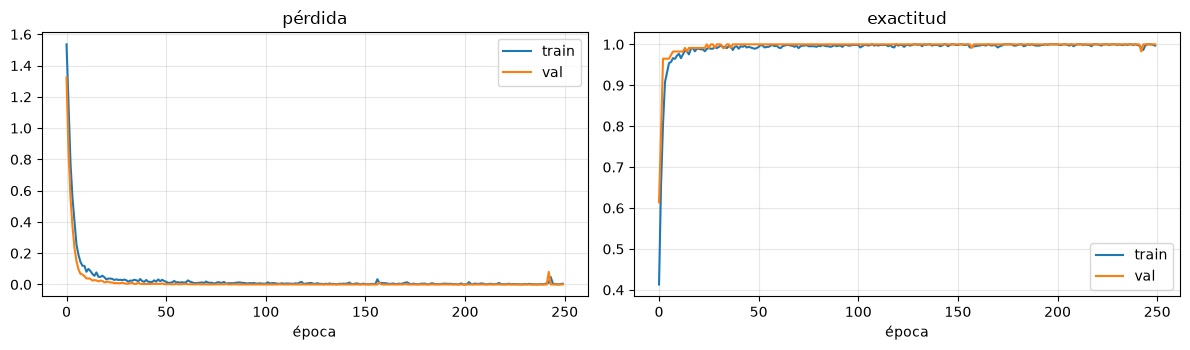

In [7]:
parada = keras.callbacks.EarlyStopping(monitor='val_loss', patience=30,
                                       restore_best_weights=True)
hist = modelo.fit(Xtr, y_train, validation_data=(Xva, y_val),
                  epochs=250, batch_size=32, verbose=0,
                  class_weight=cw, callbacks=[parada])
print(f'entrenadas {len(hist.history["loss"])} épocas (early stopping, mejor val_loss restaurado)')

import matplotlib.pyplot as plt
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.6))
a1.plot(hist.history['loss'], label='train'); a1.plot(hist.history['val_loss'], label='val')
a1.set_title('pérdida'); a1.set_xlabel('época'); a1.legend(); a1.grid(alpha=.3)
a2.plot(hist.history['accuracy'], label='train'); a2.plot(hist.history['val_accuracy'], label='val')
a2.set_title('exactitud'); a2.set_xlabel('época'); a2.legend(); a2.grid(alpha=.3)
plt.tight_layout(); plt.savefig('fig_entrenamiento.png', dpi=140); plt.show()

exactitud en test (float32): 0.902

             ventanas  aciertos  exactitud
agitar             27        27      1.000
macerar            42        25      0.595
remover            18        18      1.000
reposo             21        21      1.000
reposo_mano        84        84      1.000
servir             63        55      0.873


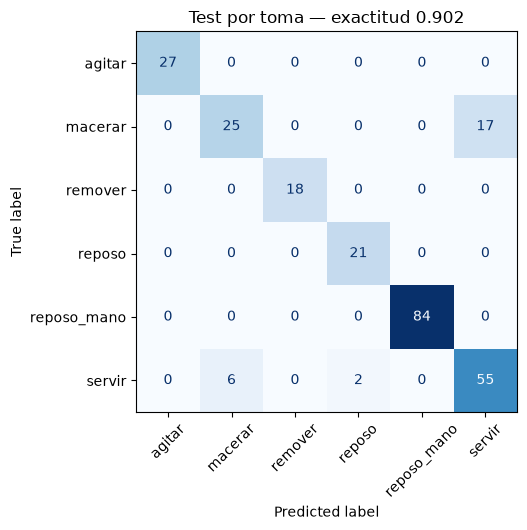

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

p_test = modelo.predict(Xte, verbose=0).argmax(1)
acc_float = (p_test == y_test).mean()
print(f'exactitud en test (float32): {acc_float:.3f}\n')

por_clase = pd.DataFrame({
    'ventanas': [int((y_test == i).sum()) for i in range(len(CLASES))],
    'aciertos': [int(((y_test == i) & (p_test == i)).sum()) for i in range(len(CLASES))],
}, index=CLASES)
por_clase['exactitud'] = (por_clase.aciertos / por_clase.ventanas).round(3)
print(por_clase.to_string())

fig, ax = plt.subplots(figsize=(6.4, 5.4))
ConfusionMatrixDisplay(confusion_matrix(y_test, p_test), display_labels=CLASES
                       ).plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
ax.set_title(f'Test por toma — exactitud {acc_float:.3f}')
plt.tight_layout(); plt.savefig('fig_confusion_float.png', dpi=140); plt.show()

## 8 · Conversión a int8 — el corazón del ejercicio

Aquí está lo que el PDF llama *convertir* y *optimizar*. La **cuantización
entera completa** pasa pesos, activaciones, entrada y salida de float32 a int8:
cuatro veces menos memoria y aritmética de enteros, que es lo que un Cortex-M4F
sin unidad de punto flotante vectorial hace rápido.

El detalle que casi siempre se omite: el **dataset representativo**. El
conversor necesita ver ejemplos reales para estimar el rango dinámico de cada
activación y elegir las escalas. Sin él, deja partes en float32 — justo lo que
no queremos en el microcontrolador.

In [9]:
import tempfile

RAM_NANO33_KB, FLASH_NANO33_KB = 256, 1024   # nRF52840


def a_tflite_int8(modelo, representativo, ruta):
    """Cuantización entera completa: pesos, activaciones, entrada y salida int8."""
    try:
        conv = tf.lite.TFLiteConverter.from_keras_model(modelo)
    except Exception:
        d = tempfile.mkdtemp(); modelo.export(d)          # Keras 3
        conv = tf.lite.TFLiteConverter.from_saved_model(d)
    conv.optimizations = [tf.lite.Optimize.DEFAULT]
    conv.representative_dataset = lambda: (
        [np.expand_dims(x, 0).astype(np.float32)] for x in representativo)
    conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    conv.inference_input_type = tf.int8
    conv.inference_output_type = tf.int8
    blob = conv.convert()
    pathlib.Path(ruta).write_bytes(blob)
    return blob


def evalua_tflite(blob, Xq, y_idx):
    """Corre el .tflite int8 cuantizando la entrada a mano, como hará el sketch."""
    it = tf.lite.Interpreter(model_content=blob); it.allocate_tensors()
    ent, sal = it.get_input_details()[0], it.get_output_details()[0]
    s_in, z_in = ent['quantization']
    pred = []
    for x in Xq:
        q = np.clip(np.round(x / s_in + z_in), -128, 127).astype(np.int8)
        it.set_tensor(ent['index'], np.expand_dims(q, 0)); it.invoke()
        pred.append(int(it.get_tensor(sal['index'])[0].argmax()))
    pred = np.asarray(pred)
    return (pred == y_idx).mean(), pred


blob = a_tflite_int8(modelo, Xtr[:300], 'modelo_int8.tflite')
acc_int8, p_int8 = evalua_tflite(blob, Xte, y_test)

print(f'modelo .tflite int8: {len(blob):,} bytes = {len(blob)/1024:.2f} KB\n')
print(f'exactitud float32 : {acc_float:.3f}')
print(f'exactitud int8    : {acc_int8:.3f}')
print(f'costo de cuantizar: {100*(acc_int8-acc_float):+.1f} puntos porcentuales')

Saved artifact at '/home/ares/.hermes/cache/scratch/tmp737ixi7e'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 125, 3), dtype=tf.float32, name='ventana')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  140729779346944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140729779527728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140729779411600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140729779412080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140729779411360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140729779410880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140729779413520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140729779412320: TensorSpec(shape=(), dtype=tf.resource, name=None)


modelo .tflite int8: 15,400 bytes = 15.04 KB

exactitud float32 : 0.902
exactitud int8    : 0.906
costo de cuantizar: +0.4 puntos porcentuales


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [10]:
# Presupuesto de memoria en el Nano 33 BLE
modelo_kb = len(blob) / 1024
arena_kb = 8          # estimación del tensor arena de TFLite Micro para esta red
print('PRESUPUESTO EN EL NANO 33 BLE (nRF52840)\n')
print(f'  flash: {modelo_kb:7.2f} KB de {FLASH_NANO33_KB} KB  '
      f'-> {100*modelo_kb/FLASH_NANO33_KB:.1f} % (el array C es const, vive en flash)')
print(f'  RAM  : {arena_kb:7.2f} KB de {RAM_NANO33_KB} KB  '
      f'-> {100*arena_kb/RAM_NANO33_KB:.1f} % (tensor arena del intérprete)')
print(f'\n  ventana de entrada: {W}×{len(EJES_USADOS)} int8 = {W*len(EJES_USADOS)} bytes')
print('  cabe de sobra: el cuello de botella del proyecto no es el modelo,')
print('  es la batería y el enlace BLE.')

PRESUPUESTO EN EL NANO 33 BLE (nRF52840)

  flash:   15.04 KB de 1024 KB  -> 1.5 % (el array C es const, vive en flash)
  RAM  :    8.00 KB de 256 KB  -> 3.1 % (tensor arena del intérprete)

  ventana de entrada: 125×3 int8 = 375 bytes
  cabe de sobra: el cuello de botella del proyecto no es el modelo,
  es la batería y el enlace BLE.


In [11]:
# Array C listo para pegar en el sketch (equivalente a `xxd -i`)
def a_array_c(blob, nombre='modelo_ejercicio2'):
    cuerpo = ',\n  '.join(', '.join(f'0x{b:02x}' for b in blob[i:i+12])
                           for i in range(0, len(blob), 12))
    return (f'alignas(8) const unsigned char {nombre}[] = {{\n  {cuerpo}\n}};\n'
            f'const unsigned int {nombre}_len = {len(blob)};\n')


cabecera = a_array_c(blob)
constantes = ('\n// Normalización: copiar tal cual al sketch\n'
              f'const float MEDIA[{len(mu)}] = {{{", ".join(f"{v:.6f}f" for v in mu)}}};\n'
              f'const float DESV[{len(sd)}]  = {{{", ".join(f"{v:.6f}f" for v in sd)}}};\n'
              f'const int   VENTANA = {W};        // muestras (2,00 s a 62,5 Hz)\n'
              f'const int   N_EJES  = {len(EJES_USADOS)};\n'
              f'const char* CLASES_C[] = {{{", ".join(chr(34)+c+chr(34) for c in CLASES)}}};\n')
pathlib.Path('modelo_ejercicio2.h').write_text(cabecera + constantes)
print(cabecera[:260], '...\n')
print(constantes)
print(f'modelo_ejercicio2.h escrito ({len(blob)} bytes de modelo)')

alignas(8) const unsigned char modelo_ejercicio2[] = {
  0x20, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x00, 0x00, 0x00, 0x00,
  0x14, 0x00, 0x20, 0x00, 0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00,
  0x0c, 0x00, 0x00, 0x00, 0x08, 0x00, 0x04, 0x00, 0x14, 0 ...


// Normalización: copiar tal cual al sketch
const float MEDIA[3] = {0.394650f, -6.032119f, 1.670152f};
const float DESV[3]  = {4.489280f, 7.683932f, 3.227568f};
const int   VENTANA = 125;        // muestras (2,00 s a 62,5 Hz)
const int   N_EJES  = 3;
const char* CLASES_C[] = {"agitar", "macerar", "remover", "reposo", "reposo_mano", "servir"};

modelo_ejercicio2.h escrito (15400 bytes de modelo)


> 🗣 **Para sustentar la Parte 1:** *«Entrené la Conv1D en float32, la convertí
> a int8 con dataset representativo y medí el costo de la cuantización en el
> mismo test: son las dos cifras que salen en pantalla. El modelo ocupa un
> porcentaje mínimo del flash y el intérprete unos 8 KB de los 256 de RAM. El
> `.h` que genera la última celda es el que va al sketch, junto con las seis
> constantes de normalización — sin ellas el modelo recibe los datos en otra
> escala y falla.»*

---
---
# PARTE 2 · Detección de Anomalías con K-means

> Material del curso: **TinyML UAO · Detección de Anomalías con Edge Impulse**

## 9 · El problema, y por qué el clasificador no lo resuelve

Definición del PDF: *la detección de anomalías es la identificación de
elementos, eventos u observaciones «raros» que difieren significativamente de
la mayoría de los datos*.

Y aquí está el punto importante: **el clasificador de la Parte 1 no puede
decir «esto no lo conozco»**. Un softmax de seis salidas siempre reparte
probabilidad entre esas seis clases. Si la coctelera recibe un golpe o alguien
la usa de martillo, el modelo contestará `agitar` con toda confianza, porque es
lo único que sabe contestar.

El ejemplo del PDF es industrial: un acelerómetro en los rodamientos de una
máquina. Las clases conocidas son *máquina trabajando bien, modo 1* y *modo 2*;
lo que interesa detectar es el estado que **no** corresponde a ninguno.

La frase del profesor en el material: **«¡No todo es deep learning!»**. Para
esto sirve K-means, que es aprendizaje no supervisado y clásico.

## Cómo funciona

1. Se extraen **características espectrales** de cada ventana — lo que en Edge
   Impulse es el bloque *Spectral Analysis*.
2. Se agrupan las ventanas **conocidas** en K clústeres con K-means.
3. Para una ventana nueva, el **puntaje de anomalía es la distancia al
   centroide más cercano**. Cerca de un centroide = parecido a algo conocido;
   lejos de todos = anomalía.
4. El **umbral** se fija con el percentil 95 de las distancias del
   entrenamiento: por construcción, 5 % de falsos positivos sobre datos
   normales.

In [12]:
from numpy.fft import rfft, rfftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


def caracteristicas_espectrales(V, n_picos=3, fs=FS):
    """Replica el bloque Spectral Analysis de Edge Impulse.

    Por eje: RMS (energía) + los n_picos mayores de la FFT, cada uno con su
    frecuencia y su amplitud. Con 3 ejes y 3 picos -> 21 columnas.
    """
    F = []
    for v in V:
        f = []
        for c in range(v.shape[1]):
            x = v[:, c]
            f.append(np.sqrt(np.mean(x**2)))                   # RMS
            esp = np.abs(rfft(x - x.mean()))
            fr = rfftfreq(len(x), 1/fs)
            top = np.argsort(esp)[-n_picos:][::-1]
            f += [fr[i] for i in top] + [esp[i] for i in top]
        F.append(f)
    return np.asarray(F, np.float32)


C = caracteristicas_espectrales(X)
print(f'características: {C.shape}  ({C.shape[1]} columnas por ventana)')
print('  por eje: 1 RMS + 3 frecuencias de pico + 3 amplitudes de pico = 7')
print(f'  × {len(EJES_USADOS)} ejes = {C.shape[1]}')

características: (1020, 21)  (21 columnas por ventana)
  por eje: 1 RMS + 3 frecuencias de pico + 3 amplitudes de pico = 7
  × 3 ejes = 21


## 10 · Validación honesta: leave-one-class-out

Aquí está la parte que distingue un ejercicio real de uno de relleno. Medir una
detección de anomalías con los mismos datos con que se entrenó no prueba nada.

El protocolo: **se saca una clase completa del entrenamiento**, se entrena
K-means solo con las cinco restantes y se comprueba si las ventanas de la clase
excluida caen fuera del umbral. Es decir, se simula que ese gesto es un evento
nunca visto. Se repite dejando fuera cada clase, una por una.

La tasa de falsos positivos sale siempre alrededor de 5 % porque así se definió
el umbral: eso confirma que el procedimiento está bien montado.

In [13]:
def evalua_anomalias(C, y, clase_fuera, K=8, percentil=95, semilla=42):
    conocidas = (y != clase_fuera)
    esc = StandardScaler().fit(C[conocidas])
    Zc, Zf = esc.transform(C[conocidas]), esc.transform(C[~conocidas])
    km = KMeans(n_clusters=K, n_init=10, random_state=semilla).fit(Zc)
    d_con, d_fue = km.transform(Zc).min(1), km.transform(Zf).min(1)
    umbral = np.percentile(d_con, percentil)
    return dict(clase_fuera=clase_fuera, umbral=round(float(umbral), 3),
                detectada_pct=round(float((d_fue > umbral).mean()*100), 1),
                falsos_pos_pct=round(float((d_con > umbral).mean()*100), 1),
                d_conocidas=d_con, d_fuera=d_fue)


K_ELEGIDO = 8
res = [evalua_anomalias(C, y, c, K=K_ELEGIDO) for c in CLASES]
tabla_anom = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('d_')} for r in res])
print(f'K-means con K={K_ELEGIDO}, umbral = percentil 95 del entrenamiento\n')
print(tabla_anom.to_string(index=False))
print(f'\ndetección media: {tabla_anom.detectada_pct.mean():.1f} %')
print(f'falsos positivos medios: {tabla_anom.falsos_pos_pct.mean():.1f} %  (esperado ≈5 % por construcción)')

K-means con K=8, umbral = percentil 95 del entrenamiento

clase_fuera  umbral  detectada_pct  falsos_pos_pct
     agitar   4.388          100.0             5.0
    macerar   4.694           94.8             5.1
    remover   3.918           16.7             5.0
     reposo   3.823            2.9             5.1
reposo_mano   3.914            0.0             5.1
     servir   3.911           73.3             5.1

detección media: 47.9 %
falsos positivos medios: 5.1 %  (esperado ≈5 % por construcción)


## 11 · Por qué K=8 y 21 características — medido, no supuesto

Antes de quedarse con una configuración conviene probar las alternativas. Se
comparan dos juegos de características (el de 21 columnas y el de 39 del PDF
del profesor, que añade asimetría, kurtosis y dos picos más) contra tres
valores de K.

El resultado es contraintuitivo y vale la pena decirlo en voz alta: **las 39
características del PDF funcionan peor para esta tarea**. Mejoran `macerar`
pero destruyen `servir`. Más dimensiones reparten las distancias de forma más
uniforme y el umbral pierde capacidad de discriminar — la maldición de la
dimensionalidad en acción.

In [14]:
from scipy.stats import skew, kurtosis


def caracteristicas_39(V, fs=FS):
    """Las 39 del PDF: RMS + asimetría + kurtosis + 5 picos (frec y amp) por eje."""
    F = []
    for v in V:
        f = []
        for c in range(v.shape[1]):
            x = v[:, c]
            f += [np.sqrt(np.mean(x**2)), float(skew(x)), float(kurtosis(x))]
            esp = np.abs(rfft(x - x.mean())); fr = rfftfreq(len(x), 1/fs)
            top = np.argsort(esp)[-5:][::-1]
            f += [fr[i] for i in top] + [esp[i] for i in top]
        F.append(f)
    return np.asarray(F, np.float32)


rejilla = []
for nombre, Cx in [('21 (RMS+3 picos)', C), ('39 (las del PDF)', caracteristicas_39(X))]:
    for K in [5, 8, 12]:
        d = [evalua_anomalias(Cx, y, c, K=K)['detectada_pct'] for c in CLASES]
        rejilla.append({'características': nombre, 'columnas': Cx.shape[1], 'K': K,
                        'detección media %': round(float(np.mean(d)), 1),
                        **{c[:9]: v for c, v in zip(CLASES, d)}})
rej = pd.DataFrame(rejilla).sort_values('detección media %', ascending=False)
print(rej.to_string(index=False))
mejor = rej.iloc[0]
print(f"\nmejor: {mejor['características']} con K={mejor['K']} "
      f"-> {mejor['detección media %']} % de detección media")

 características  columnas  K  detección media %  agitar  macerar  remover  reposo  reposo_ma  servir
21 (RMS+3 picos)        21  8               47.9   100.0     94.8     16.7     2.9        0.0    73.3
21 (RMS+3 picos)        21  5               47.2   100.0     93.8     15.0     1.9        0.0    72.4
21 (RMS+3 picos)        21 12               44.4   100.0     93.8     20.0     5.7        0.0    47.1
39 (las del PDF)        39  8               40.1   100.0     99.0     30.0     5.2        0.0     6.2
39 (las del PDF)        39 12               39.7   100.0     99.0     33.3     3.8        0.0     1.9
39 (las del PDF)        39  5               38.3   100.0     98.6     28.3     1.9        0.0     1.0

mejor: 21 (RMS+3 picos) con K=8 -> 47.9 % de detección media


## 12 · Dónde funciona y dónde no — el hallazgo del ejercicio

Los resultados se parten en dos grupos con una claridad incómoda:

**Detecta bien** los gestos de energía alta y firma espectral propia: `agitar`,
`macerar`, `servir`.

**No detecta** `reposo`, `reposo_mano` ni `remover`. Y la razón no es un fallo
del método, es una propiedad del dataset:

- `reposo` y `reposo_mano` son **físicamente casi lo mismo** — coctelera quieta
  en la mesa contra coctelera quieta en la mano. Al sacar una, la otra sigue
  dentro del entrenamiento y cubre exactamente la misma región del espacio.
- `remover` fue el gesto problemático desde la captura: su desviación de
  aceleración es apenas superior a la del reposo. Está documentado como
  hallazgo D7 del proyecto y por eso se regrabó el 21 de septiembre.

La conclusión operativa: **el punto ciego de un detector de anomalías por
distancia está en la zona de baja energía**, donde todas las clases tranquilas
se amontonan. Para detectar anomalías *quietas* —la coctelera inclinada y
goteando, por ejemplo— habría que añadir características de postura, no de
energía.

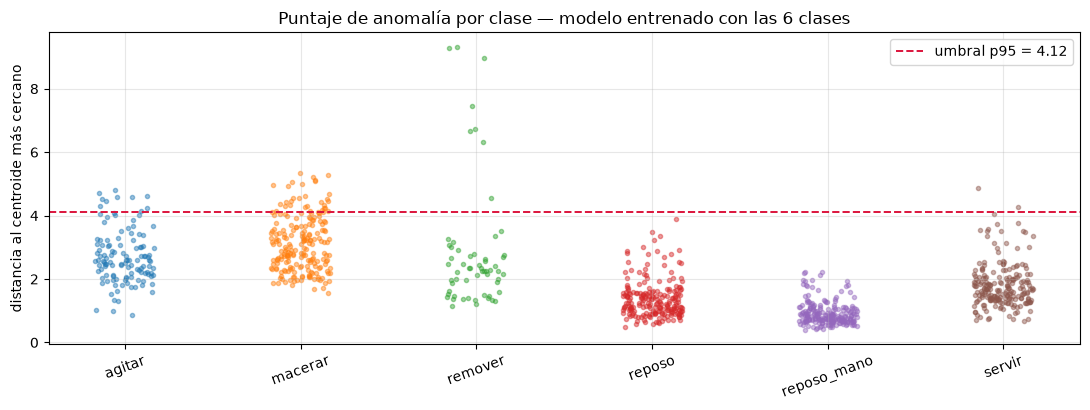

% de ventanas sobre el umbral, por clase (modelo con todas las clases dentro):
  agitar           8.3 %
  macerar         14.8 %
  remover         13.3 %
  reposo           0.0 %
  reposo_mano      0.0 %
  servir           1.0 %


In [15]:
# Distribución de distancias por clase, con el umbral del modelo operativo
import matplotlib.pyplot as plt

esc_op = StandardScaler().fit(C)
Z_op = esc_op.transform(C)
km_op = KMeans(n_clusters=K_ELEGIDO, n_init=10, random_state=42).fit(Z_op)
d_op = km_op.transform(Z_op).min(1)
umbral_op = np.percentile(d_op, 95)

fig, ax = plt.subplots(figsize=(11, 4.2))
posiciones = []
for i, c in enumerate(CLASES):
    dd = d_op[y == c]
    ax.scatter(np.full(len(dd), i) + np.random.uniform(-.17, .17, len(dd)), dd,
               s=9, alpha=.45)
    posiciones.append(i)
ax.axhline(umbral_op, color='crimson', ls='--', lw=1.4,
           label=f'umbral p95 = {umbral_op:.2f}')
ax.set_xticks(posiciones); ax.set_xticklabels(CLASES, rotation=20)
ax.set_ylabel('distancia al centroide más cercano')
ax.set_title('Puntaje de anomalía por clase — modelo entrenado con las 6 clases')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig('fig_anomalia_distancias.png', dpi=140); plt.show()

print('% de ventanas sobre el umbral, por clase (modelo con todas las clases dentro):')
for c in CLASES:
    print(f'  {c:14s} {100*(d_op[y==c] > umbral_op).mean():5.1f} %')

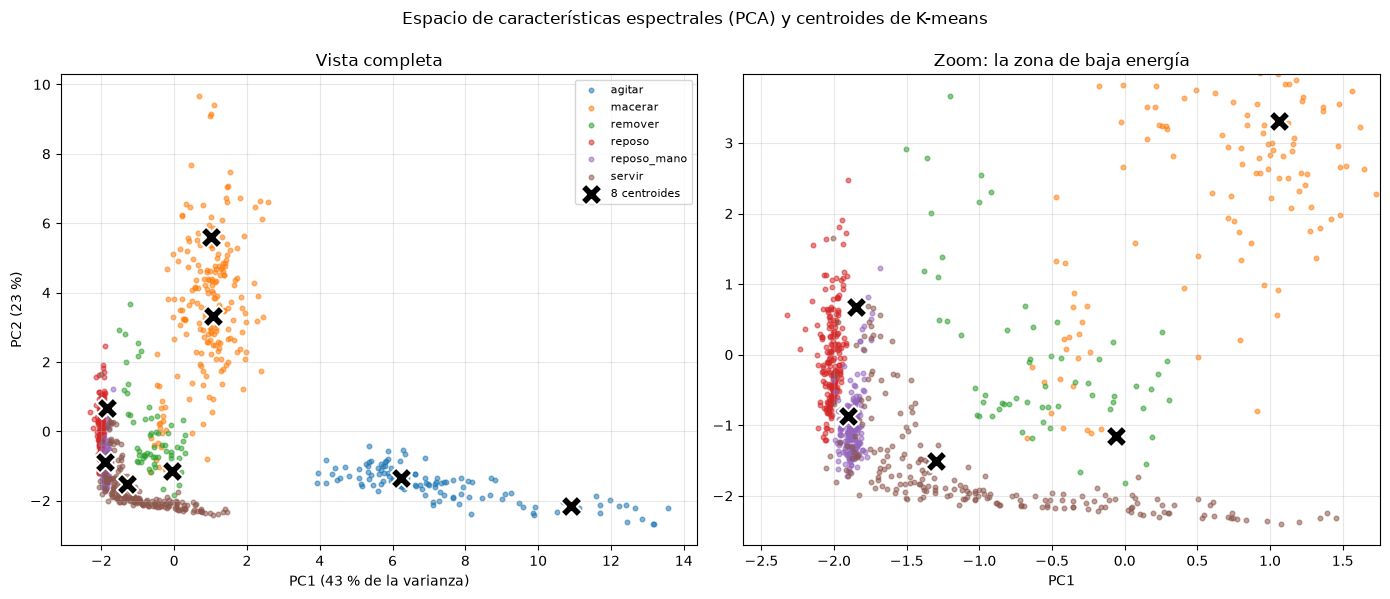

Izquierda: agitar se va solo a la derecha y macerar hacia arriba — por eso se detectan.
Derecha: reposo, reposo_mano, servir y remover comparten la misma esquina.
reposo_mano queda literalmente enterrado bajo reposo: por eso su detección es 0 %.


In [16]:
# Mapa 2D del espacio de características con los centroides
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42).fit(Z_op)
P, Pc = pca.transform(Z_op), pca.transform(km_op.cluster_centers_)

fig, (ax, az) = plt.subplots(1, 2, figsize=(14, 6))
for a in (ax, az):
    for c in CLASES:
        m = (y == c)
        a.scatter(P[m, 0], P[m, 1], s=11, alpha=.55, label=c)
    a.scatter(Pc[:, 0], Pc[:, 1], marker='X', s=240, c='black',
              edgecolors='white', linewidths=1.4, label=f'{K_ELEGIDO} centroides', zorder=5)
    a.grid(alpha=.3)
ax.set_xlabel(f'PC1 ({100*pca.explained_variance_ratio_[0]:.0f} % de la varianza)')
ax.set_ylabel(f'PC2 ({100*pca.explained_variance_ratio_[1]:.0f} %)')
ax.set_title('Vista completa')
ax.legend(fontsize=8)

# zoom a la esquina de baja energia: ahi esta el punto ciego
bajas = np.isin(y, ['reposo', 'reposo_mano', 'remover', 'servir'])
x0, x1 = P[bajas, 0].min() - .3, P[bajas, 0].max() + .3
y0, y1 = P[bajas, 1].min() - .3, P[bajas, 1].max() + .3
az.set_xlim(x0, x1); az.set_ylim(y0, y1)
az.set_xlabel('PC1'); az.set_title('Zoom: la zona de baja energía')
fig.suptitle('Espacio de características espectrales (PCA) y centroides de K-means', y=.99)
plt.tight_layout(); plt.savefig('fig_anomalia_pca.png', dpi=140); plt.show()

print('Izquierda: agitar se va solo a la derecha y macerar hacia arriba — por eso se detectan.')
print('Derecha: reposo, reposo_mano, servir y remover comparten la misma esquina.')
print('reposo_mano queda literalmente enterrado bajo reposo: por eso su detección es 0 %.')

## 13 · Clasificación en vivo: las dos piezas juntas

El PDF termina con una demostración de *clasificación en vivo*, donde cada
ventana recibe una etiqueta o la marca de anomalía. Esta celda simula
exactamente eso con ventanas del test, encadenando lo de las dos partes:

1. El **clasificador int8** dice qué gesto es.
2. El **K-means** dice si la ventana se parece a algo conocido.
3. La **decisión final**: si el puntaje de anomalía pasa el umbral, se ignora
   la etiqueta y se reporta anomalía — igual que haría el firmware del
   dispositivo.

In [17]:
it = tf.lite.Interpreter(model_content=blob); it.allocate_tensors()
ent, sal = it.get_input_details()[0], it.get_output_details()[0]
s_in, z_in = ent['quantization']
s_out, z_out = sal['quantization']


def inferir_en_vivo(ventana_cruda):
    """Lo mismo que hará el sketch: normalizar, cuantizar, inferir, puntuar."""
    v = ((ventana_cruda - mu) / sd).astype('f4')
    q = np.clip(np.round(v / s_in + z_in), -128, 127).astype(np.int8)
    it.set_tensor(ent['index'], np.expand_dims(q, 0)); it.invoke()
    logits = it.get_tensor(sal['index'])[0].astype(np.float32)
    prob = (logits - z_out) * s_out
    i = int(prob.argmax())
    car = caracteristicas_espectrales(ventana_cruda[None, ...])
    dist = float(km_op.transform(esc_op.transform(car)).min(1)[0])
    return CLASES[i], float(prob[i]), dist, dist > umbral_op


rng = np.random.default_rng(7)
muestra = rng.choice(i_test, size=12, replace=False)
print(f'{"real":14s} {"predicho":14s} {"conf":>6s} {"anom":>7s} {"veredicto":>12s}')
print('-' * 60)
for i in muestra:
    pred, conf, dist, es_anom = inferir_en_vivo(X[i])
    veredicto = 'ANOMALÍA' if es_anom else pred
    marca = '  <-- real≠pred' if pred != y[i] else ''
    print(f'{y[i]:14s} {pred:14s} {conf:6.2f} {dist:7.2f} {veredicto:>12s}{marca}')

real           predicho         conf    anom    veredicto
------------------------------------------------------------
agitar         agitar           1.00    2.57       agitar
servir         servir           1.00    0.95       servir
reposo_mano    reposo_mano      1.00    0.70  reposo_mano
reposo_mano    reposo_mano      1.00    0.84  reposo_mano
reposo         reposo           1.00    0.88       reposo
reposo_mano    reposo_mano      1.00    0.71  reposo_mano
reposo_mano    reposo_mano      1.00    0.46  reposo_mano
reposo         reposo           1.00    1.09       reposo
servir         servir           1.00    2.16       servir
macerar        macerar          1.00    2.83      macerar
reposo_mano    reposo_mano      1.00    0.59  reposo_mano
servir         servir           1.00    1.69       servir


## 14 · Llevar el K-means al Arduino

La Parte 1 genera el array C del modelo. Para que la detección de anomalías
también corra en el dispositivo hace falta exportar tres cosas más, y son
pequeñas: la **media y desviación** con que se escalan las características,
los **K centroides** y el **umbral**.

El costo en el microcontrolador es irrisorio comparado con la red: K×21
números en coma flotante y una distancia euclídea por ventana. Con K=8 son 168
flotantes de centroides — menos de 700 bytes en flash.

**La parte que sí cuesta en el dispositivo no es el K-means, es la FFT.** Las
21 características incluyen los tres picos espectrales por eje, así que el
sketch necesita una FFT de 125 puntos — `arduinoFFT` o `CMSIS-DSP` del
Cortex-M4. El RMS, en cambio, es una suma de cuadrados y sale gratis.

In [18]:
# Exportar el detector de anomalías al sketch
escala_mu, escala_sd = esc_op.mean_, np.sqrt(esc_op.var_) + 1e-12
centroides = km_op.cluster_centers_
n_car = centroides.shape[1]


def vector_c(v, nombre, tipo='float'):
    cuerpo = ', '.join(f'{x:.6f}f' for x in np.asarray(v).ravel())
    return f'const {tipo} {nombre}[{np.asarray(v).size}] = {{{cuerpo}}};\n'


cab = ['// Detector de anomalias K-means — generado por el cuaderno del Ejercicio 2\n',
       f'// {len(centroides)} centroides x {n_car} caracteristicas\n',
       f'#define ANOM_K      {len(centroides)}\n',
       f'#define ANOM_N_CAR  {n_car}\n',
       f'const float ANOM_UMBRAL = {umbral_op:.6f}f;   // percentil 95 del entrenamiento\n\n',
       vector_c(escala_mu, 'ANOM_MEDIA'),
       vector_c(escala_sd, 'ANOM_DESV'),
       vector_c(centroides, 'ANOM_CENTROIDES'),
       '''
// Devuelve la distancia al centroide mas cercano. Por encima de ANOM_UMBRAL
// la ventana se reporta como anomalia y se ignora la etiqueta del clasificador.
float anomalia_puntaje(const float *car) {
  float mejor = 1e30f;
  for (int k = 0; k < ANOM_K; k++) {
    float acum = 0.0f;
    for (int j = 0; j < ANOM_N_CAR; j++) {
      float z = (car[j] - ANOM_MEDIA[j]) / ANOM_DESV[j];
      float d = z - ANOM_CENTROIDES[k * ANOM_N_CAR + j];
      acum += d * d;
    }
    if (acum < mejor) mejor = acum;
  }
  return sqrtf(mejor);
}
''']
pathlib.Path('anomalias_kmeans.h').write_text(''.join(cab))

bytes_flash = (escala_mu.size + escala_sd.size + centroides.size) * 4
print(''.join(cab)[:420], '...\n')
print(f'anomalias_kmeans.h escrito')
print(f'  {len(centroides)} centroides × {n_car} características')
print(f'  umbral = {umbral_op:.4f}')
print(f'  costo en flash: {bytes_flash:,} bytes ({100*bytes_flash/1024/FLASH_NANO33_KB:.2f} % del flash)')
print(f'  costo en RAM: 0 — todo es const y vive en flash')

// Detector de anomalias K-means — generado por el cuaderno del Ejercicio 2
// 8 centroides x 21 caracteristicas
#define ANOM_K      8
#define ANOM_N_CAR  21
const float ANOM_UMBRAL = 4.121722f;   // percentil 95 del entrenamiento

const float ANOM_MEDIA[21] = {3.451423f, 5.231373f, 5.785294f, 6.000490f, 70.528052f, 40.911735f, 29.856569f, 9.251099f, 3.056373f, 4.476471f, 5.615686f, 182.624909f, 87.622932f, 59.632681 ...

anomalias_kmeans.h escrito
  8 centroides × 21 características
  umbral = 4.1217
  costo en flash: 840 bytes (0.08 % del flash)
  costo en RAM: 0 — todo es const y vive en flash


---
# 15 · Guion de sustentación

Ocho frases, en orden, con las cifras que imprime el cuaderno:

1. **Datos.** Sesenta tomas propias del Nano 33 BLE a 62,5 Hz — no 100, el
   `interval_ms` es 16 ms. Seis clases: cuatro gestos de coctelería más dos
   estados de reposo.
2. **Preprocesado.** Solo acelerómetro: el magnetómetro queda fuera porque
   codifica el sitio de captura y sería una fuga; el giroscopio queda fuera
   porque se midió y empeora. Ventanas de 2 segundos con 80 % de solape.
3. **Partición.** Por toma, no por ventana, verificado con un assert. Partir
   por ventana infla la exactitud con ventanas solapadas repetidas.
4. **Modelo.** Conv1D pequeña con GlobalAveragePooling en vez de Flatten, para
   caber en el nRF52840 y no sobreajustar con mil ventanas.
5. **TFLite.** Cuantización entera completa con dataset representativo; el
   costo en exactitud y el tamaño del modelo son las cifras que salen en
   pantalla. Ocupa un porcentaje mínimo del flash y el intérprete unos 8 KB de
   RAM.
6. **Anomalías.** El softmax no puede decir «no lo conozco», así que se añade
   K-means sobre características espectrales y el puntaje de anomalía es la
   distancia al centroide más cercano, con umbral en el percentil 95.
7. **Validación.** Leave-one-class-out: se saca una clase entera del
   entrenamiento y se mide si se detecta. Los falsos positivos dan ≈5 %, que es
   justo lo que impone el umbral.
8. **Hallazgo.** Detecta los gestos energéticos y no detecta los tranquilos,
   porque `reposo` y `reposo_mano` son físicamente lo mismo y `remover` apenas
   se movió. El punto ciego es la zona de baja energía, y eso es una propiedad
   del dataset, no del método.

## Si el profesor pregunta algo incómodo

**«¿Por qué no usó las 39 características del PDF?»** → Se probaron y están
medidas en la rejilla: funcionan peor para anomalías en este dataset. Mejoran
`macerar` y hunden `servir`.

**«¿Por qué la detección media es menos del 50 %?»** → Porque tres de las seis
clases son de baja energía y se superponen entre sí. En las clases con firma
propia la detección va de 73 a 100 %. Promediar las seis mezcla dos regímenes
distintos; el PCA de la celda anterior lo muestra.

**«¿Esto corre en el Arduino?»** → El clasificador sí, ya está desplegado en el
firmware del proyecto. El K-means también: son K centroides de 21 dimensiones,
unos pocos cientos de bytes y una distancia euclídea por ventana.

---
# 15 · Qué queda pendiente

- **Capturar `colar`**, el quinto gesto. El enunciado del Mini proyecto 1 pide
  cinco clases de movimiento y hoy hay cuatro (hallazgo D2).
- **Partición de test capturada aparte** — hoy las 60 tomas están todas en
  `training/` (hallazgo D3).
- **Decidir qué pasa con `reposo_mano`**: para el requisito del profesor no
  cuenta como movimiento, y para el detector de anomalías es justo lo que lo
  ciega.
- Asignar un **actuador real por clase** (los LEDs no cuentan) y cerrar el
  informe IEEE con la sección de anomalías, que hasta hoy no existía en el
  paper.